
========== DATASET OVERVIEW ==========
Shape: (17049, 18)

Columns:
['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City', 'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount', 'Payment_Method', 'Device_Type', 'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer', 'Delivery_Time_Days', 'Customer_Rating']

First 5 rows:
       Order_ID Customer_ID        Date  Age Gender      City  \
0  ORD_000001-1  CUST_00001  2023-05-29   40   Male    Ankara   
1  ORD_000001-2  CUST_00001  2023-10-12   40   Male    Ankara   
2  ORD_000001-3  CUST_00001  2023-12-05   40   Male    Ankara   
3  ORD_000002-1  CUST_00002  2023-05-11   33   Male  Istanbul   
4  ORD_000002-2  CUST_00002  2023-06-16   33   Male  Istanbul   

  Product_Category  Unit_Price  Quantity  Discount_Amount  Total_Amount  \
0            Books       29.18         1             0.00         29.18   
1    Home & Garden      644.40         1           138.05        506.35   
2           Spo

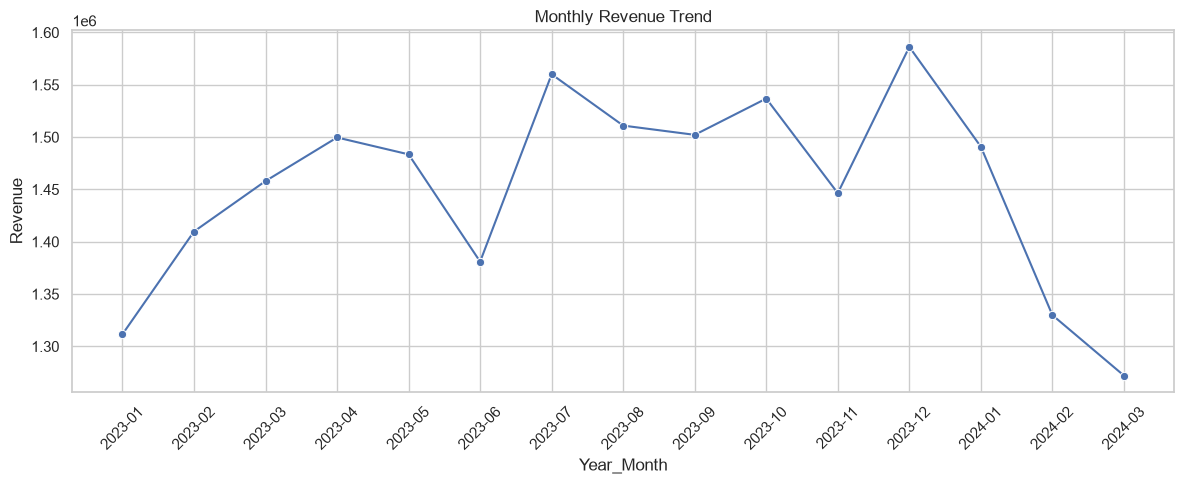

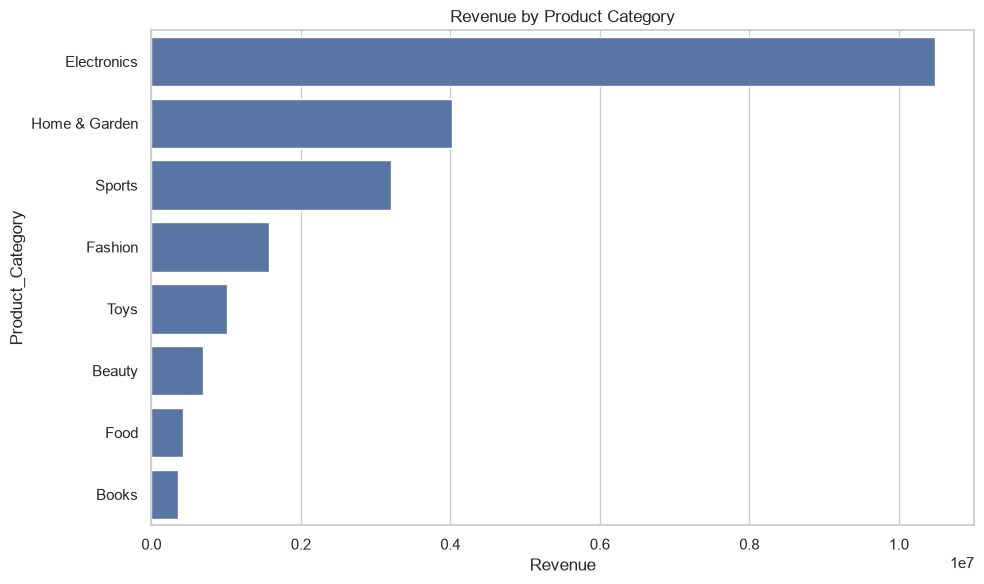

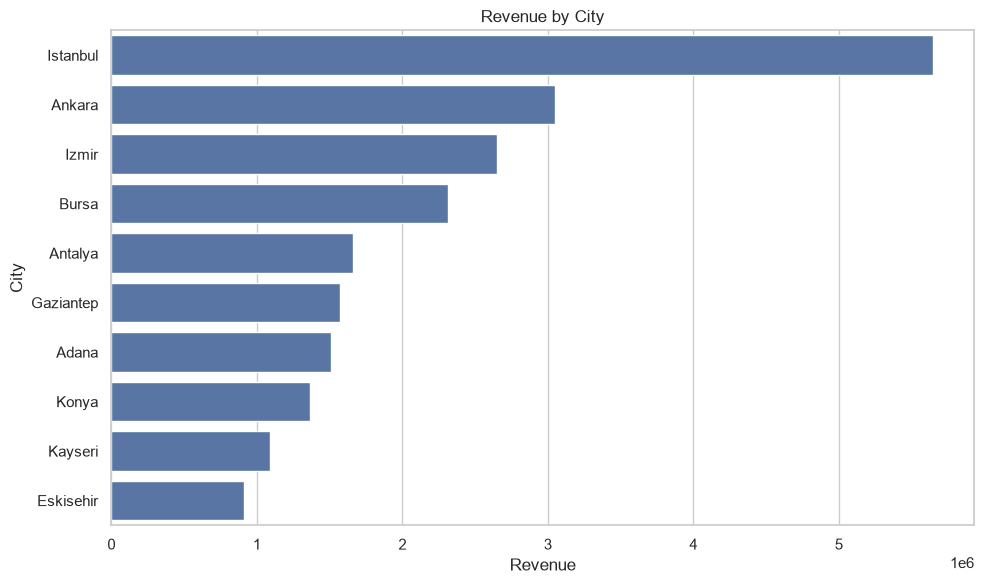

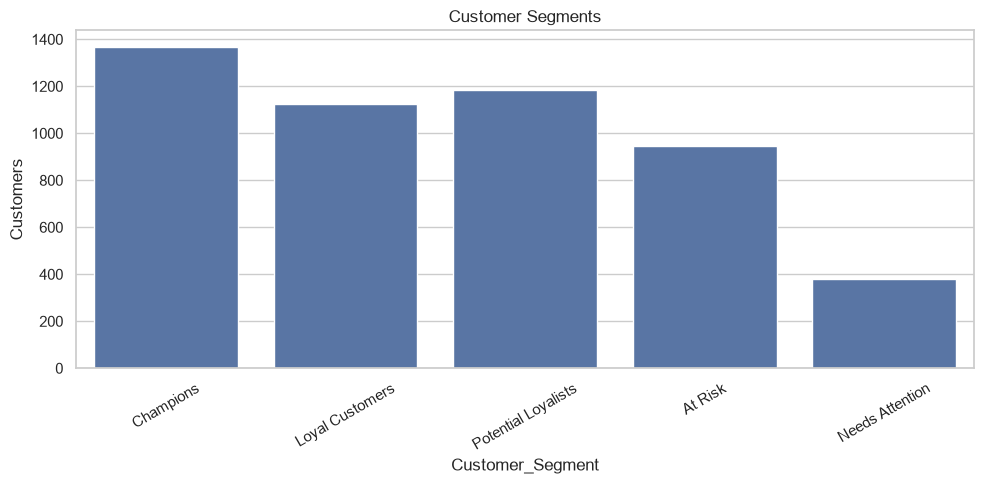

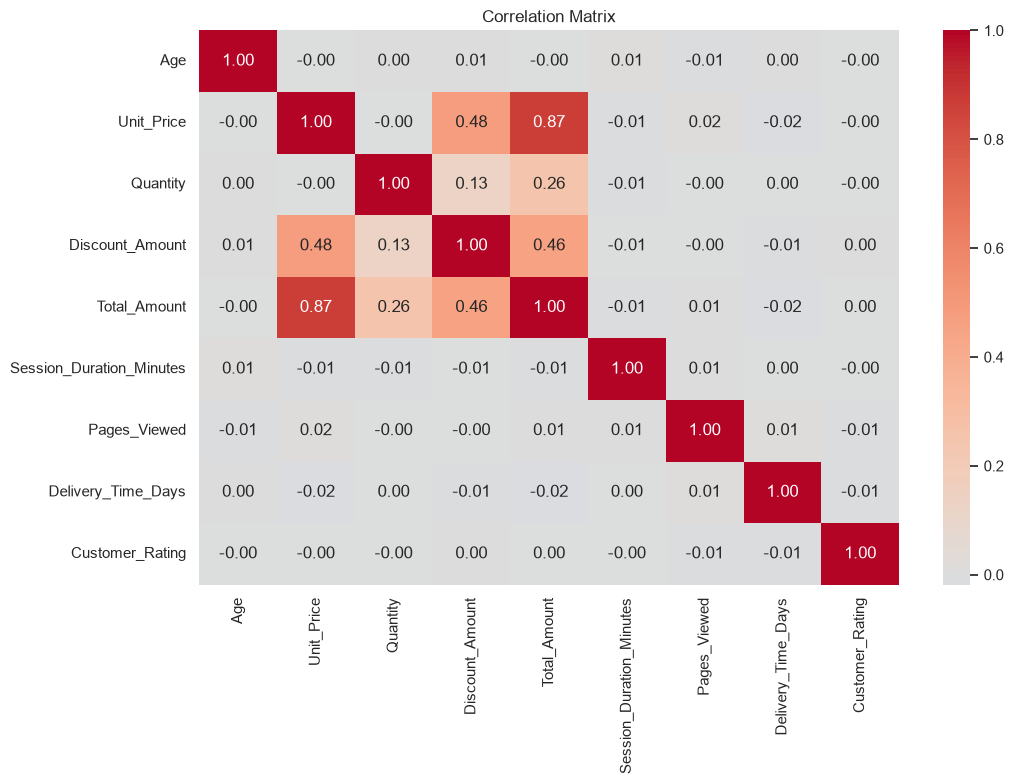


ANALYSIS COMPLETE

Dataset rows: 17,049
Revenue: 21,779,052.59
Orders: 17,049
Customers: 5,000
Average Order Value: 1,277.44
Repeat Customer Rate: 82.16%
Average Rating: 3.90
Average Delivery Time: 6.50 days

Processed datasets saved successfully.


In [1]:
# ============================================================
# E-COMMERCE SALES & CUSTOMER BEHAVIOR ANALYTICS
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

df = pd.read_csv("../data/ecommerce_customer_behavior_dataset_v2.csv")

print("\n========== DATASET OVERVIEW ==========")
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)


# ------------------------------------------------------------
# 2. DATA QUALITY CHECK
# ------------------------------------------------------------

print("\n========== DATA QUALITY ==========")

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nUnique Customers:")
print(df["Customer_ID"].nunique())

print("\nUnique Orders:")
print(df["Order_ID"].nunique())


# ------------------------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------------------------

# Convert Date to datetime
df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# Remove exact duplicate rows
df = df.drop_duplicates()

# Remove records missing critical identifiers
df = df.dropna(
    subset=[
        "Order_ID",
        "Customer_ID",
        "Date",
        "Total_Amount"
    ]
)

# Ensure numeric columns are numeric
numeric_columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount_Amount",
    "Total_Amount",
    "Session_Duration_Minutes",
    "Pages_Viewed",
    "Delivery_Time_Days",
    "Customer_Rating"
]

for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")


# ------------------------------------------------------------
# 4. FEATURE ENGINEERING
# ------------------------------------------------------------

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)
df["Day_of_Week"] = df["Date"].dt.day_name()

# Calculate gross amount before discount
df["Gross_Amount"] = (
    df["Unit_Price"] * df["Quantity"]
)

# Effective discount percentage
df["Discount_Percentage"] = np.where(
    df["Gross_Amount"] > 0,
    (df["Discount_Amount"] / df["Gross_Amount"]) * 100,
    0
)


# ------------------------------------------------------------
# 5. CORE KPIs
# ------------------------------------------------------------

total_revenue = df["Total_Amount"].sum()

total_orders = df["Order_ID"].nunique()

total_customers = df["Customer_ID"].nunique()

total_units = df["Quantity"].sum()

average_order_value = total_revenue / total_orders

average_rating = df["Customer_Rating"].mean()

average_delivery = df["Delivery_Time_Days"].mean()


print("\n========== CORE KPIs ==========")

print(f"Total Revenue: {total_revenue:,.2f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Units Sold: {total_units:,}")
print(f"Average Order Value: {average_order_value:,.2f}")
print(f"Average Customer Rating: {average_rating:.2f}")
print(f"Average Delivery Time: {average_delivery:.2f} days")


# ------------------------------------------------------------
# 6. CUSTOMER ORDER FREQUENCY
# ------------------------------------------------------------

customer_orders = (
    df.groupby("Customer_ID")["Order_ID"]
    .nunique()
)

repeat_customers = (customer_orders > 1).sum()

repeat_customer_rate = (
    repeat_customers / total_customers
) * 100

print("\n========== CUSTOMER RETENTION ==========")

print(f"Repeat Customers: {repeat_customers:,}")
print(f"Repeat Customer Rate: {repeat_customer_rate:.2f}%")


# ------------------------------------------------------------
# 7. MONTHLY SALES ANALYSIS
# ------------------------------------------------------------

monthly_sales = (
    df.groupby("Year_Month")
    .agg(
        Revenue=("Total_Amount", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
    .reset_index()
)

monthly_sales["AOV"] = (
    monthly_sales["Revenue"] /
    monthly_sales["Orders"]
)

print("\n========== MONTHLY SALES ==========")
print(monthly_sales)


# ------------------------------------------------------------
# 8. CATEGORY ANALYSIS
# ------------------------------------------------------------

category_analysis = (
    df.groupby("Product_Category")
    .agg(
        Revenue=("Total_Amount", "sum"),
        Orders=("Order_ID", "nunique"),
        Units_Sold=("Quantity", "sum"),
        Customers=("Customer_ID", "nunique"),
        Average_Rating=("Customer_Rating", "mean")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

category_analysis["AOV"] = (
    category_analysis["Revenue"] /
    category_analysis["Orders"]
)

print("\n========== CATEGORY PERFORMANCE ==========")
print(category_analysis)


# ------------------------------------------------------------
# 9. CITY ANALYSIS
# ------------------------------------------------------------

city_analysis = (
    df.groupby("City")
    .agg(
        Revenue=("Total_Amount", "sum"),
        Orders=("Order_ID", "nunique"),
        Customers=("Customer_ID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

city_analysis["AOV"] = (
    city_analysis["Revenue"] /
    city_analysis["Orders"]
)

print("\n========== CITY PERFORMANCE ==========")
print(city_analysis)


# ------------------------------------------------------------
# 10. DEVICE ANALYSIS
# ------------------------------------------------------------

device_analysis = (
    df.groupby("Device_Type")
    .agg(
        Revenue=("Total_Amount", "sum"),
        Orders=("Order_ID", "nunique"),
        Avg_Session=("Session_Duration_Minutes", "mean"),
        Avg_Pages=("Pages_Viewed", "mean"),
        Avg_Rating=("Customer_Rating", "mean")
    )
    .reset_index()
)

device_analysis["AOV"] = (
    device_analysis["Revenue"] /
    device_analysis["Orders"]
)

print("\n========== DEVICE ANALYSIS ==========")
print(device_analysis)


# ------------------------------------------------------------
# 11. PAYMENT METHOD ANALYSIS
# ------------------------------------------------------------

payment_analysis = (
    df.groupby("Payment_Method")
    .agg(
        Revenue=("Total_Amount", "sum"),
        Orders=("Order_ID", "nunique")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

print("\n========== PAYMENT METHODS ==========")
print(payment_analysis)


# ------------------------------------------------------------
# 12. DELIVERY & CUSTOMER SATISFACTION
# ------------------------------------------------------------

delivery_analysis = (
    df.groupby("Delivery_Time_Days")
    .agg(
        Average_Rating=("Customer_Rating", "mean"),
        Orders=("Order_ID", "nunique")
    )
    .reset_index()
)

print("\n========== DELIVERY VS RATING ==========")
print(delivery_analysis)


# ------------------------------------------------------------
# 13. CUSTOMER-LEVEL ANALYSIS
# ------------------------------------------------------------

customer_summary = (
    df.groupby("Customer_ID")
    .agg(
        Last_Purchase=("Date", "max"),
        First_Purchase=("Date", "min"),
        Frequency=("Order_ID", "nunique"),
        Monetary=("Total_Amount", "sum"),
        Avg_Order_Value=("Total_Amount", "mean"),
        Avg_Rating=("Customer_Rating", "mean")
    )
    .reset_index()
)


# ------------------------------------------------------------
# 14. RFM ANALYSIS
# ------------------------------------------------------------

# Use one day after the latest transaction as reference date
reference_date = df["Date"].max() + pd.Timedelta(days=1)

rfm = (
    df.groupby("Customer_ID")
    .agg(
        Recency=("Date", lambda x: (reference_date - x.max()).days),
        Frequency=("Order_ID", "nunique"),
        Monetary=("Total_Amount", "sum")
    )
    .reset_index()
)

# Score Recency: lower recency = better
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    4,
    labels=[4, 3, 2, 1]
).astype(int)

# Score Frequency
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

# Score Monetary
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    4,
    labels=[1, 2, 3, 4]
).astype(int)

rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)


# ------------------------------------------------------------
# 15. CUSTOMER SEGMENTATION
# ------------------------------------------------------------

def assign_segment(score):

    if score >= 10:
        return "Champions"

    elif score >= 8:
        return "Loyal Customers"

    elif score >= 6:
        return "Potential Loyalists"

    elif score >= 4:
        return "At Risk"

    else:
        return "Needs Attention"


rfm["Customer_Segment"] = (
    rfm["RFM_Score"].apply(assign_segment)
)

segment_analysis = (
    rfm.groupby("Customer_Segment")
    .agg(
        Customers=("Customer_ID", "count"),
        Revenue=("Monetary", "sum"),
        Avg_Recency=("Recency", "mean"),
        Avg_Frequency=("Frequency", "mean"),
        Avg_Spend=("Monetary", "mean")
    )
    .reset_index()
    .sort_values("Revenue", ascending=False)
)

segment_analysis["Revenue_Share_%"] = (
    segment_analysis["Revenue"] /
    segment_analysis["Revenue"].sum()
) * 100

print("\n========== RFM CUSTOMER SEGMENTS ==========")
print(segment_analysis)


# ------------------------------------------------------------
# 16. ADD CUSTOMER SEGMENT TO MAIN DATA
# ------------------------------------------------------------

df = df.merge(
    rfm[
        [
            "Customer_ID",
            "Recency",
            "Frequency",
            "Monetary",
            "Customer_Segment"
        ]
    ],
    on="Customer_ID",
    how="left"
)


# ------------------------------------------------------------
# 17. CORRELATION ANALYSIS
# ------------------------------------------------------------

correlation_columns = [
    "Age",
    "Unit_Price",
    "Quantity",
    "Discount_Amount",
    "Total_Amount",
    "Session_Duration_Minutes",
    "Pages_Viewed",
    "Delivery_Time_Days",
    "Customer_Rating"
]

correlation_matrix = (
    df[correlation_columns]
    .corr()
)

print("\n========== CORRELATION MATRIX ==========")
print(correlation_matrix.round(2))


# ------------------------------------------------------------
# 18. BASIC VISUALIZATIONS
# ------------------------------------------------------------

sns.set_theme(style="whitegrid")


# Monthly Revenue

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=monthly_sales,
    x="Year_Month",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Category Revenue

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_analysis,
    x="Revenue",
    y="Product_Category"
)

plt.title("Revenue by Product Category")
plt.tight_layout()
plt.show()


# Revenue by City

plt.figure(figsize=(10, 6))

sns.barplot(
    data=city_analysis,
    x="Revenue",
    y="City"
)

plt.title("Revenue by City")
plt.tight_layout()
plt.show()


# Customer Segments

plt.figure(figsize=(10, 5))

sns.barplot(
    data=segment_analysis,
    x="Customer_Segment",
    y="Customers"
)

plt.title("Customer Segments")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Correlation Heatmap

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 19. SAVE PROCESSED FILES
# ------------------------------------------------------------

os.makedirs("../data/processed", exist_ok=True)

df.to_csv(
    "../data/processed/ecommerce_cleaned.csv",
    index=False
)

rfm.to_csv(
    "../data/processed/customer_segments.csv",
    index=False
)

monthly_sales.to_csv(
    "../data/processed/monthly_sales.csv",
    index=False
)

category_analysis.to_csv(
    "../data/processed/category_analysis.csv",
    index=False
)

city_analysis.to_csv(
    "../data/processed/city_analysis.csv",
    index=False
)


# ------------------------------------------------------------
# 20. FINAL SUMMARY
# ------------------------------------------------------------

print("\n========================================")
print("ANALYSIS COMPLETE")
print("========================================")

print(f"""
Dataset rows: {len(df):,}
Revenue: {total_revenue:,.2f}
Orders: {total_orders:,}
Customers: {total_customers:,}
Average Order Value: {average_order_value:,.2f}
Repeat Customer Rate: {repeat_customer_rate:.2f}%
Average Rating: {average_rating:.2f}
Average Delivery Time: {average_delivery:.2f} days
""")

print("Processed datasets saved successfully.")